# Jordan Titanic Data Features
**Author:** Jordan  
**Date:** November 14, 2025 <br>
**Objective:** Compare Ordinary Least Squares, Ridge, Elastic Net, and Polynomial Regression Models.


## Introduction
In this project, we use the Titanic dataset to build and evaluate four regression models: Ordinary Least Squares, Ridge, Elastic Net, and Polynomial. We will compare model performance and reflect on their effectiveness for predicting passenger fare.

## Imports
First, we import the necessary Python libraries for our analysis. 

In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

## Section 1. Load and Inspect the Data

Next, we load the Titanic dataset from seaborn and view its head.

In [73]:
titanic_df: pd.DataFrame = sns.load_dataset("titanic")
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Section 2. Data Exploration and Preparation

We impute missing values for 'age' using the median, binary encode 'sex', and drop the rows with missing fare.  Then, we add the feature 'family_size', number of family members on board, by counting sibsp (number of siblings or spouses on board), parch (number of parents or children on board), and 1 to count the individual. Finally, we binary encode 'sex'.

In [74]:
median_age = titanic_df["age"].median()
titanic_df["age"] = titanic_df["age"].fillna(median_age)

titanic_df["sex"] = titanic_df["sex"].map({"male": 1, "female": 0})

titanic_df = titanic_df.dropna(subset=["fare"])

titanic_df["family_size"] = titanic_df["sibsp"] + titanic_df["parch"] + 1

## Section 3. Feature Selection and Justification

With regression in mind, we now select input and target features for our model.  We will consider the following four different cases for our models:

In [75]:
# Case 1: age
X1 = titanic_df[["age"]]
y1 = titanic_df["fare"]

# Case 2: family_size
X2 = titanic_df[["family_size"]]
y2 = titanic_df["fare"]

# Case 3: age and family size
X3 = titanic_df[["age", "family_size"]]
y3 = titanic_df["fare"]

# Case 4: sex
X4 = titanic_df[["sex"]]
y4 = titanic_df["fare"]

Reflection 3:

1) Why might these features affect a passenger’s fare:

   Age should be a good predictor of fare, since people in their middle age, in their peak earning years, may be more likely to afford an upper-class ticket.  The family size feature could show to be a good predictor of fare due to people traveling in groups getting a discount or an increase in fare for having to book a larger room to accommidate the family.
2) List all available features:

    The available features are: 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', and 'family_size'
3) Which other features could improve predictions and why:  
 
   Pclass will undoubtedly be a good predictor of fare, since upper-class tickets were of a higher price.  Deck should also be a great predictor of fare, due to certain decks only housing cabins for specific price and luxury ranges.
5) How many variables are in your Case 4:
 
   There is one variable in Case 4, 'sex'.
6) Which variable(s) did you choose for Case 4 and why do you feel those could make good inputs:
   
   The variable of 'sex' was chosen as a predictor for fare, since during the time period of the titanic disaster women who traveled alone were more likely to be upper-class passengers.

## Section 4. Train a Regression Model (Linear Regression)

In this section, we will train an Ordinary Least Squares Regression Model.

### 4.1 Split the Data

First, we split our data for each case.

In [76]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=123)

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=123)

### 4.2 Train, Predict, and Report Linear Regression Models (all 4 cases)

We now train and predict each model, then give a performance report.

In [77]:
linear_dict: dict = {
    "Case 1: Age": (X1_train, X1_test, y1_train, y1_test),
    "Case 2: Family Size": (X2_train, X2_test, y2_train, y2_test),
    "Case 3: Age + Family Size": (X3_train, X3_test, y3_train, y3_test),
    "Case 4: Sex": (X4_train, X4_test, y4_train, y4_test)
}

linear_y_pred_test: dict = {}

for case, (X_train, X_test, y_train, y_test) in linear_dict.items():

    lr_model = LinearRegression().fit(X_train, y_train)
    y_pred_train = lr_model.predict(X_train)
    linear_y_pred_test[case] = lr_model.predict(X_test)

    print(f"{case}")
    print("-"*len(case))
    print(f"{'Training R²:':<{12}} {r2_score(y_train, y_pred_train):>.3f}")
    print(f"{'Test R²:':<{12}} {r2_score(y_test, linear_y_pred_test[case]):>.3f}")
    print(f"{'Test RMSE:':<{12}} {root_mean_squared_error(y_test, linear_y_pred_test[case]):>.2f}")
    print(f"{'Test MAE:':<{12}} {mean_absolute_error(y_test, linear_y_pred_test[case]):>.2f}\n")

Case 1: Age
-----------
Training R²: 0.010
Test R²:     0.003
Test RMSE:   37.97
Test MAE:    25.29

Case 2: Family Size
-------------------
Training R²: 0.050
Test R²:     0.022
Test RMSE:   37.61
Test MAE:    25.03

Case 3: Age + Family Size
-------------------------
Training R²: 0.073
Test R²:     0.050
Test RMSE:   37.08
Test MAE:    24.28

Case 4: Sex
-----------
Training R²: 0.024
Test R²:     0.099
Test RMSE:   36.10
Test MAE:    24.24



### Reflection 4:

Compare the train vs test results.

All four of our cases show severe underfitting.  This is evident by the consistently low R² scores on both the training and testing sets for all cases, where the models were not complex enough to capture any underlying patterns in the fare feature.  With such low R² scores, virtually none of the variability in the 'fare' feature was explained by any of the input feature cases. No signs of overfitting were detected, since there was no significant degradation of metrics from testing to training sets for all the cases.

Adding Age

1) Did adding age improve the model:  
   
   Yes, there was a slight improvement to the models performance from adding 'age' to the 'family_size' case.  There was an increase in test R² score from 0.022 for the case of only 'family_size' to to 0.050 for the case of 'family_size' and 'age'.
2) Propose a possible explanation:

   The slight improvement in R² scores from adding the 'age' feature suggests the combined feature model could possibly be identifying subpopulations in the dataset that had a difference in average fare patterns.  

Worst

1) Which case performed the worst:
 
   Case 1: Age performed the worst.
2) How do you know:

   The test R² score was the lowest at 0.003 for the case only having 'age' as a predicting feature.  Meaning that virtually none of the variability in the predicting feature 'fare' was explained by the predicting feature 'age'.  This is compounded by the model also having the highest test error performance metrics, with a RMSE of 37.97 and MAE of 25.29.
3) Do you think adding more training data would improve it (and why/why not): 

   No, I do not believe adding more training data will improve the model, since the input feature of 'age' has demonstrated such a weak relationship with the target feature 'fare'.

Best

1) Which case performed the best:
 
   Case 4: Sex performed the best.
2) How do you know:

   The case for the input feature of only 'sex' had the lowest test error metrics of all the models, RSME of 36.10 and MAE of 24.24, and the highest test R² score of 0.099.
3) Do you think adding more training data would improve it (and why/why not): 

   No, due to the significant underfiting of the model demonstrated by such a low test R² score of 0.099, I do not believe adding more training data will add any significant improvement to the model.

## Section 5. Compare Alternative Models

In this section, we will compare the alternate regression methods of Ridge, Elastic Net, and Polynomial to Linear Regression.

### 5.1 Ridge Regression (L2 Penalty)

First, we train and predict a Ridge Regression Model for Case 4: Sex.

In [78]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X4_train, y4_train)
y_pred_ridge = ridge_model.predict(X4_test)

### 5.2 Elastic Net (L1 + L2 combined)

Next, we train and predict an Elastic Net Regression Model for Case 4: Sex.

In [79]:
elastic_model = ElasticNet(alpha=0.3, l1_ratio=0.5)
elastic_model.fit(X4_train, y4_train)
y_pred_elastic = elastic_model.predict(X4_test)

### 5.3 Polynomial Regression

Then, we train and predict a Polynomial Cubic Fit Model for Case 1: Age.

In [80]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X1_train)
X_test_poly = poly.transform(X1_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y1_train)
y_pred_poly = poly_model.predict(X_test_poly)

### 5.4 Visualize Polynomial Cubic Fit

Now, we visualize our Polynomial Cubic Fit Model for Case 1: Age.

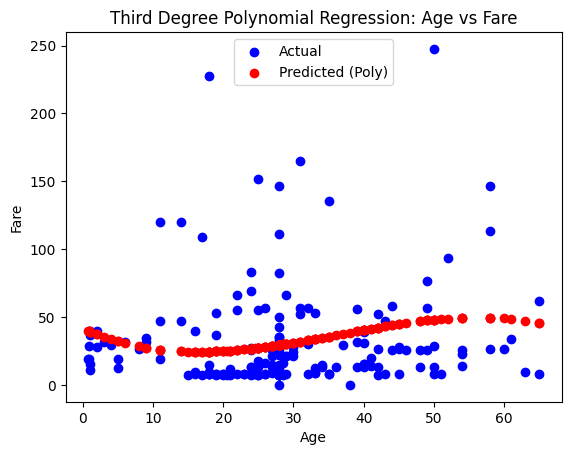

In [81]:
plt.scatter(X1_test, y1_test, color="blue", label="Actual")
plt.scatter(X1_test, y_pred_poly, color="red", label="Predicted (Poly)")
plt.legend()
plt.gca().set(xlabel="Age", ylabel="Fare", title="Third Degree Polynomial Regression: Age vs Fare")
plt.show()

### Reflection 5.4:

1) What patterns does the cubic model seem to capture:

    Inspection of the plot for the cubic model reveals that the model does not seem to capture any significant pattern in the data.

2) Where does it perform well or poorly:

    The model performs poorly accross all ranges of fare, particularly for fares above the range of 70, according to the plot.
3) Did the polynomial fit outperform linear regression:

    No, the polynomial fit did not outperform the linear regression model.  Both models failed to capture any significant pattern in the data.
4) Where (on the graph or among which kinds of data points) does it fit best:

    According to the plot, the polynomial model fits best for the age group of 8-10 years for the fare value of approximately 35 and for the age group of 27-30 years for the fare values ranging approximately from 25-40.

### 5.5 Compare All Models

At this stage, we compare the performance of all our models.

In [82]:
def report(name, y_true, y_pred):  # noqa: D103
    print(f"{name}")
    print("-"*len(name))
    print(f"{'R²:':<{5}} {r2_score(y_true, y_pred):>.3f}")
    print(f"{'RMSE:':<{5}} {root_mean_squared_error(y_true, y_pred):>.2f}")
    print(f"{'MAE:':<{5}} {mean_absolute_error(y_true, y_pred):>.2f}\n")

report("Linear", y4_test, linear_y_pred_test["Case 4: Sex"])
report("Ridge", y4_test, y_pred_ridge)
report("ElasticNet", y4_test, y_pred_elastic)
report("Polynomial", y1_test, y_pred_poly)

Linear
------
R²:   0.099
RMSE: 36.10
MAE:  24.24

Ridge
-----
R²:   0.099
RMSE: 36.10
MAE:  24.24

ElasticNet
----------
R²:   0.068
RMSE: 36.71
MAE:  24.33

Polynomial
----------
R²:   -0.003
RMSE: 38.10
MAE:  25.30



### 5.6 Visualize Higher Order Polynomial

Finally, we visualize a sixth degree Polynomial Fit Model for Case 1: Age.

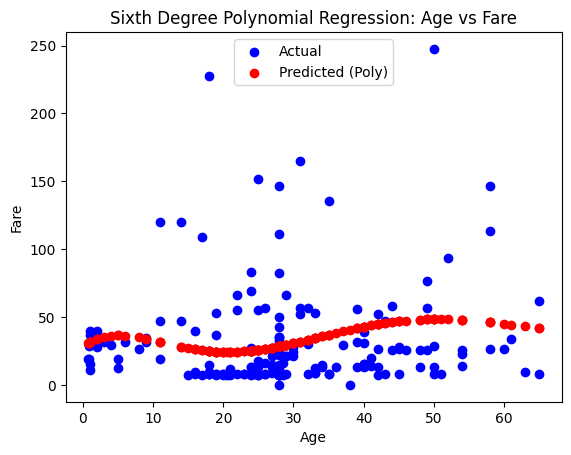

In [83]:
poly6 = PolynomialFeatures(degree=6)
X_train_poly6 = poly6.fit_transform(X1_train)
X_test_poly6 = poly6.transform(X1_test)

poly_model6 = LinearRegression()
poly_model6.fit(X_train_poly6, y1_train)
y_pred_poly6 = poly_model6.predict(X_test_poly6)

plt.scatter(X1_test, y1_test, color="blue", label="Actual")
plt.scatter(X1_test, y_pred_poly6, color="red", label="Predicted (Poly)")
plt.legend()
plt.gca().set(xlabel="Age", ylabel="Fare", title="Sixth Degree Polynomial Regression: Age vs Fare")
plt.show()

Inspection of the plot indicates the the sixth degree polynomial model does slightly capture the data better than the third degree polynomial model for the age groups of 0-5 and 20-29 years.

## Section 6. Final Thoughts & Insights

In this section, we give our final thoughts and insights of our analysis.


### 6.1 Summarize Findings

| Model Type  | Case | Features Used | R² | RMSE | MAE |
|-------------|------|---------------|----------|-----------|--------|
| Linear      | Case 1 | age | 0.003 | 37.97 | 25.29 |
|             | Case 2 | family_size | 0.022 | 37.61 | 25.03 |
|             | Case 3 | age + family_size | 0.050 | 37.08 | 24.28 |
|             | Case 4 | sex | 0.099 | 36.10 | 24.24 |
|-------------|--------|-------------------|----------|-----------|--------|
| Ridge       | Case 4 | sex | 0.099 | 36.10 | 24.24 |
|-------------|--------|-------------------|----------|-----------|--------|
| Elastic Net | Case 4 | sex | 0.054 | 36.99 | 24.21 |
|-------------|--------|-------------------|----------|-----------|--------|
| Polynomial  | Case 1 | age | -0.003 | 38.10 | 25.30 |

1) What features were most useful?

    None of the features demonstrated a sufficient explanation of the variability in the target feature.  In contrast, the features could be considered useful in demonstrating the complexity of the dataset and need for further investigaton.

2) What regression model performed best?

    The regression model for the fourth case utilizing the only iput feature 'sex' performed the best, with the lowest test error metrics of all the models, RSME of 36.10 and MAE of 24.24, and the highest test R² score of 0.099.

3) How did model complexity or regularization affect results?

    Due to the severe underfitting of all our models, based on extremely low test R² scores, model complexity and regularization had little to no effect on results.

### 6.2 Discuss Challenges

1) Was fare hard to predict? Why?

    Fare was extremely hard to predict with the given methods due to low test R² score and high test error metrics for all cases, where all test error metrics were above a value of 25 relative to the mean fare value of 32.20 and the highest test R² score was 0.099.

1) Did skew or outliers impact the models?

    Based on previous investigations, the 'fare' feature was highly right-hand skewed with many outliers.  The skewness and outliers are most likely the reason all our models performed poorly based on performance metrics, since skewness and outliers have an adverse effect on the loss function of all regression models.

### 6.3 Optional Next Steps

1) Try different features besides the ones used (e.g., pclass, sex if you didn't use them this time)

2) Try predicting age instead of fare

3) Explore log transformation of fare to reduce skew

4) Utilize RANSAC and Huber Regressors with a Polynomial Fit Model to reduce impact from skewness and outliers.